# Customer Churn Prediction
## Preprocessing Technique 02 — Encoding Categorical Variables
**Member: Aathmika-IT25103234**

This notebook follows the structure of the uploaded encoding reference notebook and is adapted to the **Churn_Modelling.csv** dataset.

### Main tasks
- Load the cleaned churn dataset
- Inspect categorical variables
- Separate features and target
- Remove identifier columns
- Perform EDA before encoding
- Encode `Gender`
- One-Hot Encode `Geography`
- Visualize encoded features
- Prepare train/test data
- Save the encoded dataset for the next preprocessing stage


In [28]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

import warnings
warnings.filterwarnings("ignore")


## 1. Load Dataset

This notebook first looks for the output of Notebook 01:

`01_cleaned_missing_duplicates.csv`

If that file is not available, it falls back to the original `Churn_Modelling.csv`.


In [29]:
from google.colab import files

uploaded = files.upload()

Saving 01_cleaned_missing_duplicates.csv to 01_cleaned_missing_duplicates (1).csv


In [30]:
from pathlib import Path

possible_paths = [
    Path("/content/01_cleaned_missing_duplicates.csv"),
    Path("01_cleaned_missing_duplicates.csv"),
    Path("/content/Churn_Modelling.csv"),
    Path("Churn_Modelling.csv")
]

file_path = None

for path in possible_paths:
    if path.exists():
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError(
        "Upload either 01_cleaned_missing_duplicates.csv or Churn_Modelling.csv."
    )

df = pd.read_csv(file_path)

print("Loaded file:", file_path)
print("Dataset shape:", df.shape)
df.head()


Loaded file: /content/01_cleaned_missing_duplicates.csv
Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Initial Data Inspection


In [31]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows:
0


## 3. Identify Categorical Variables

In this churn dataset:

- `Gender` is a binary categorical variable.
- `Geography` is a nominal categorical variable with multiple categories.
- `Surname` is text-based identifier information and is not useful as a predictive categorical feature for this model.


In [32]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Object/Categorical columns in original dataset:")
print(categorical_columns)

for col in categorical_columns:
    print(f"\n{col} unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


Object/Categorical columns in original dataset:
['Surname', 'Geography', 'Gender']

Surname unique values: 2932
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Genovese    25
Yeh         25
Shih        25
Wright      24
Maclean     24
Name: count, dtype: int64

Geography unique values: 3
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender unique values: 2
Gender
Male      5457
Female    4543
Name: count, dtype: int64


## 4. EDA Before Encoding

Before encoding, categorical variables should be visualized to understand their distributions.


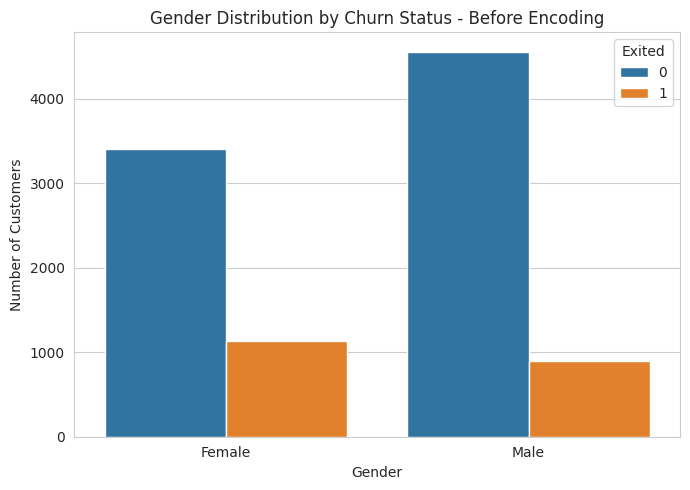

In [33]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Gender", hue="Exited")

plt.title("Gender Distribution by Churn Status - Before Encoding")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()


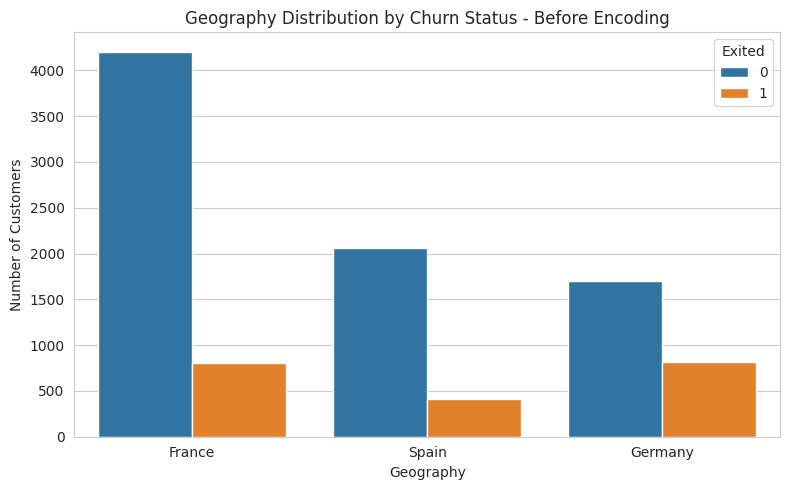

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Geography", hue="Exited")

plt.title("Geography Distribution by Churn Status - Before Encoding")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()


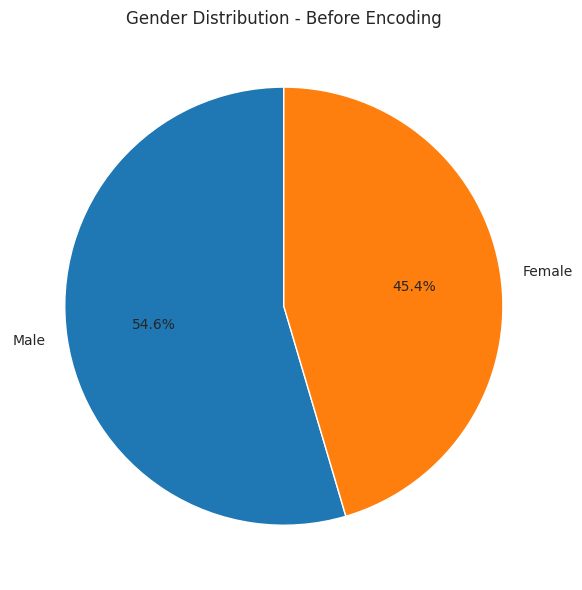

In [35]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gender Distribution - Before Encoding")
plt.tight_layout()
plt.show()


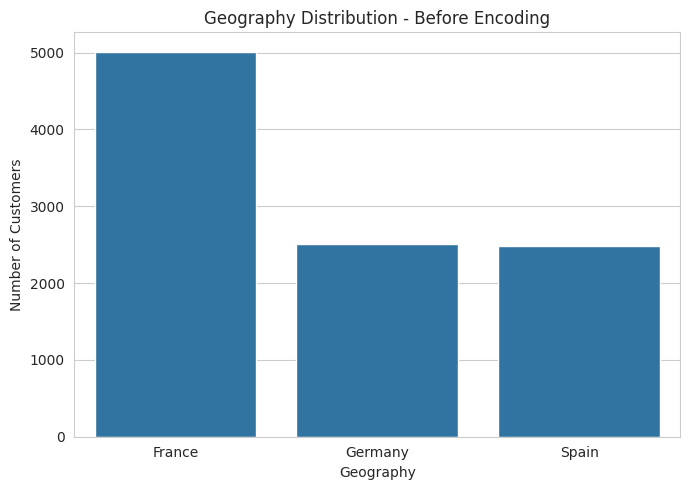

In [36]:
geo_counts = df["Geography"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=geo_counts.index, y=geo_counts.values)

plt.title("Geography Distribution - Before Encoding")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 5. Separate Features and Target

`Exited` is the target variable.

- `Exited = 0` → Customer stayed
- `Exited = 1` → Customer churned


In [37]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (10000, 13)
Target shape: (10000,)


## 6. Remove Identifier Columns

The following columns are identifiers rather than meaningful predictive features:

- `RowNumber`
- `CustomerId`
- `Surname`

Therefore, they are removed before encoding and model training.


In [38]:
identifier_columns = ["RowNumber", "CustomerId", "Surname"]

X = X.drop(columns=identifier_columns)

print("Identifier columns removed:", identifier_columns)
print("\nRemaining features:")
print(X.columns.tolist())


Identifier columns removed: ['RowNumber', 'CustomerId', 'Surname']

Remaining features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## 7. Define Categorical and Numerical Features


In [39]:
categorical_features = ["Gender", "Geography"]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)


Categorical features:
['Gender', 'Geography']

Numerical features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## 8. Encoding Strategy

### Gender
`Gender` contains only two categories, so Label Encoding is used:

- Female → 0
- Male → 1

### Geography
`Geography` is nominal and contains more than two categories, so One-Hot Encoding is used.

Using `drop_first=True` removes one dummy column and uses one country as the reference category. This helps avoid redundant dummy variables.


In [40]:
df_encoded = df.copy()

# Remove identifier columns
df_encoded = df_encoded.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Binary encoding for Gender
gender_mapping = {
    "Female": 0,
    "Male": 1
}

df_encoded["Gender"] = df_encoded["Gender"].map(gender_mapping)

# One-Hot Encoding for Geography
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Geography"],
    drop_first=True,
    dtype=int
)

print("Encoding completed.")
df_encoded.head()


Encoding completed.


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


## 9. Verify Encoded Dataset


In [41]:
print("Encoded dataset shape:", df_encoded.shape)

print("\nEncoded columns:")
print(df_encoded.columns.tolist())

print("\nData types after encoding:")
print(df_encoded.dtypes)


Encoded dataset shape: (10000, 12)

Encoded columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Data types after encoding:
CreditScore            int64
Gender                 int64
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Exited                 int64
Geography_Germany      int64
Geography_Spain        int64
dtype: object


In [42]:
print("Gender encoded values:")
print(df_encoded["Gender"].value_counts().sort_index())

geo_dummy_columns = [
    col for col in df_encoded.columns
    if col.startswith("Geography_")
]

print("\nGeography dummy columns:")
print(geo_dummy_columns)

display(df_encoded[["Gender"] + geo_dummy_columns].head(10))


Gender encoded values:
Gender
0    4543
1    5457
Name: count, dtype: int64

Geography dummy columns:
['Geography_Germany', 'Geography_Spain']


,Gender,Geography_Germany,Geography_Spain
0,0,0,0
1,0,0,1
2,0,0,0
3,0,0,0
4,0,0,1
5,1,0,1
6,1,0,0
7,0,1,0
8,1,0,0
9,1,0,0


## 10. EDA After Encoding

After encoding, the categories are represented numerically. These plots verify the encoded distributions.


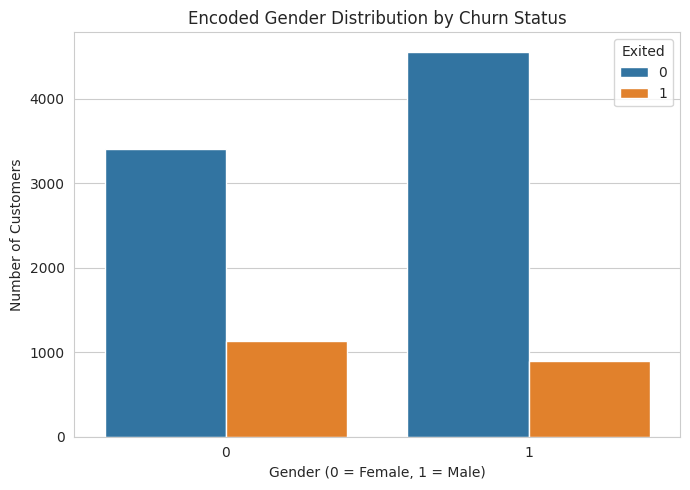

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_encoded, x="Gender", hue="Exited")

plt.title("Encoded Gender Distribution by Churn Status")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Number of Customers")
plt.legend(title="Exited")
plt.tight_layout()
plt.show()


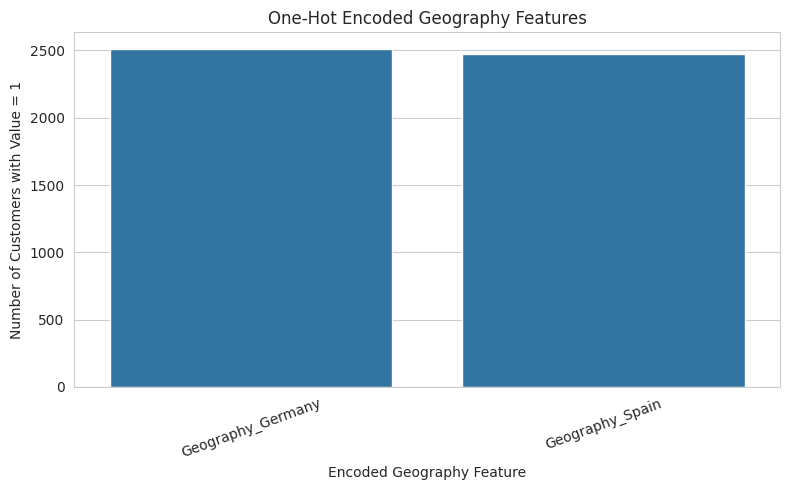

In [44]:
geo_dummy_columns = [
    col for col in df_encoded.columns
    if col.startswith("Geography_")
]

geo_dummy_counts = df_encoded[geo_dummy_columns].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=geo_dummy_counts.index,
    y=geo_dummy_counts.values
)

plt.title("One-Hot Encoded Geography Features")
plt.xlabel("Encoded Geography Feature")
plt.ylabel("Number of Customers with Value = 1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


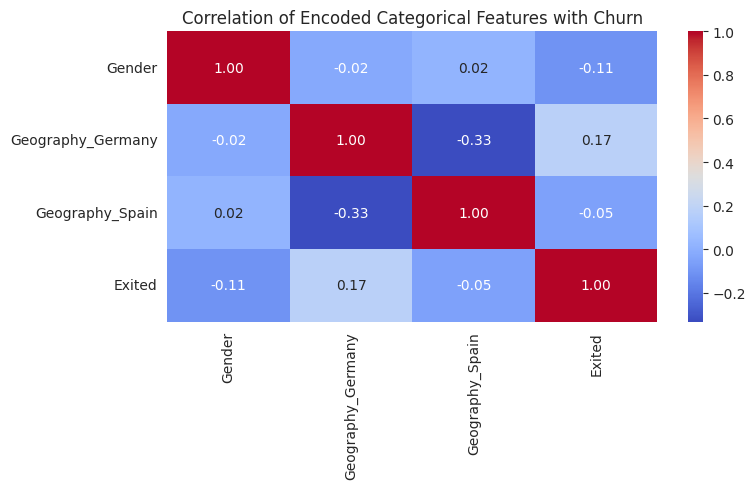

In [45]:
encoded_features = ["Gender"] + geo_dummy_columns

plt.figure(figsize=(8, 5))

sns.heatmap(
    df_encoded[encoded_features + ["Exited"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Encoded Categorical Features with Churn")
plt.tight_layout()
plt.show()


## 11. Before vs After Encoding

This section shows how the categorical columns changed after preprocessing.


In [46]:
print("BEFORE ENCODING")
display(df[["Gender", "Geography"]].head(10))

print("\nAFTER ENCODING")
display(df_encoded[["Gender"] + geo_dummy_columns].head(10))


BEFORE ENCODING


,Gender,Geography
0,Female,France
1,Female,Spain
2,Female,France
3,Female,France
4,Female,Spain
5,Male,Spain
6,Male,France
7,Female,Germany
8,Male,France
9,Male,France



AFTER ENCODING


,Gender,Geography_Germany,Geography_Spain
0,0,0,0
1,0,0,1
2,0,0,0
3,0,0,0
4,0,0,1
5,1,0,1
6,1,0,0
7,0,1,0
8,1,0,0
9,1,0,0


## 12. Train / Test Split

This follows the structure of the reference notebook and prepares the encoded data for later modelling.


In [47]:
X_encoded = df_encoded.drop("Exited", axis=1)
y_encoded = df_encoded["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)


Training features: (8000, 11)
Testing features : (2000, 11)
Training target  : (8000,)
Testing target   : (2000,)


## 13. ColumnTransformer Version

The reference notebook uses `OneHotEncoder` with `ColumnTransformer`.

The following code demonstrates the equivalent scikit-learn preprocessing approach. It is useful later when all six preprocessing stages are combined into a single machine-learning pipeline.


In [48]:
X_pipeline = df.drop(
    columns=["RowNumber", "CustomerId", "Surname", "Exited"]
)

y_pipeline = df["Exited"]

categorical_features_pipeline = ["Gender", "Geography"]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    drop="first",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            encoder,
            categorical_features_pipeline
        )
    ],
    remainder="passthrough"
)

print("ColumnTransformer created successfully.")


ColumnTransformer created successfully.


In [49]:
X_transformed = preprocessor.fit_transform(X_pipeline)

feature_names = preprocessor.get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

print("Transformed feature shape:", X_transformed_df.shape)
X_transformed_df.head()


Transformed feature shape: (10000, 11)


,categorical__Gender_Male,categorical__Geography_Germany,categorical__Geography_Spain,remainder__CreditScore,remainder__Age,remainder__Tenure,remainder__Balance,remainder__NumOfProducts,remainder__HasCrCard,remainder__IsActiveMember,remainder__EstimatedSalary
0,0.0,0.0,0.0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88
1,0.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58
2,0.0,0.0,0.0,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57
3,0.0,0.0,0.0,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63
4,0.0,0.0,1.0,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10


## 14. Save Encoded Dataset

The encoded dataset is saved so that the next preprocessing notebook can use it.

### Output
`02_encoded_churn_data.csv`


In [50]:
output_file = "02_encoded_churn_data.csv"

df_encoded.to_csv(output_file, index=False)

print(f"Encoded dataset saved as: {output_file}")
print("Final encoded dataset shape:", df_encoded.shape)


Encoded dataset saved as: 02_encoded_churn_data.csv
Final encoded dataset shape: (10000, 12)


In [51]:
from google.colab import files

files.download("02_encoded_churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

In this preprocessing stage:

- Identifier columns were removed.
- `Gender` was converted into numeric binary values.
- `Geography` was converted using One-Hot Encoding.
- EDA visualizations were produced before and after encoding.
- The encoded dataset was saved for the next preprocessing stage.

The output of this notebook can now be passed to the next team member's notebook for **Outlier Removal**.
